In [3]:
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
import networkx as nx
import pandas as pd

In [ ]:
# importing data
data_path = "/orcd/home/002/jefferyl/Lauffen/ContrastLEMBAS/Contrastive_Learning/data/raw_drug_repurposing_data.txt"

# filtering dataset to get drug name and GENE names
import re
pattern = re.compile(r'^[^\s]+|\b(?=[A-Z0-9]*[A-Z])[A-Z0-9]+\b') # matching the drug information and any known protein targets (string of capital letters and numbers) per line

broad_repurposing_dict = {}
with open(data_path) as f:
    for line in f:
        matches = pattern.findall(line)
        if matches:
            matches[0] = matches[0].replace('"', '')
        if len(matches) > 1:
            broad_repurposing_dict[matches[0]] = matches[1:]

# filtering dataset to keep drugs with known drug SMILES
import pubchempy as pcp
from tqdm import tqdm
import time
import random 

smiles_dict = {}
for idx, drug in enumerate(tqdm(broad_repurposing_dict.keys())):
    retries = 0
    while retries < 5:
        try:
            compounds = pcp.get_compounds(drug, namespace='name')
            if compounds:
                smiles = compounds[0].canonical_smiles
                smiles_dict[drug] = smiles
            else:
                smiles = None
            break
        except Exception as e:
            retries += 1
            wait = 2 ** retries + random.random()  # exponential backoff
            print(f"Error fetching {drug}: {e}. Retrying in {wait:.1f}s")
            time.sleep(wait)
    
    # Throttle every 100 drugs
    if (idx + 1) % 50 == 0:
        print("Pausing for 1 second to avoid overload...")
        time.sleep(5)



In [ ]:
print(smiles_dict)
import pickle

with open("/orcd/home/002/jefferyl/Lauffen/ContrastLEMBAS/Contrastive_Learning/data/smiles_dict.pkl", "wb") as f:
    pickle.dump(smiles_dict, f)


In [ ]:
import requests

def get_uniprot_accession(gene_name):
    url = "https://rest.uniprot.org/uniprotkb/search"
    query = f'gene_exact:{gene_name} AND organism_id:9606'
    params = {
        "query": query,
        "format": "json",
        "fields": "accession,gene_names,protein_name"
    }
    response = requests.get(url, params=params)
    response.raise_for_status()
    data = response.json()
    results = data.get("results", [])
    if not results:
        return None
    # Return first matching accession
    return results[0]["primaryAccession"]

protein_interaction_dict = {}
for idx, (drug, proteins) in enumerate(tqdm(broad_repurposing_dict.items())):
    interactions = []
    for protein in proteins:
        gene = get_uniprot_accession(protein)
        if gene is not None:
            interactions.append(gene)
        else:
            print(protein)
    protein_interaction_dict[drug] = interactions
        

In [ ]:
with open("/orcd/home/002/jefferyl/Lauffen/ContrastLEMBAS/Contrastive_Learning/data/protein_inter_dict.pkl", "wb") as f:
    pickle.dump(protein_interaction_dict, f)

In [ ]:
mols = {name: Chem.MolFromSmiles(smi) for name, smi in smiles_dict.items()}
fps = {name: AllChem.GetMorganFingerprintAsBitVect(mol, 2, 2048) 
       for name, mol in mols.items()}

In [ ]:
# getting ecfp4 dictionary

from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, rdMolDescriptors
import numpy as np
import h5py
import pickle
from tqdm import tqdm

pickle_file = "/orcd/home/002/jefferyl/Lauffen/ContrastLEMBAS/Contrastive_Learning/data/smiles_dict.pkl"

with open(pickle_file, "rb") as f:
    smiles_dict = pickle.load(f)

smiles_list = [smiles_dict[i] for i in smiles_dict]

n_bits = 2048

smiles_dict = {}

for smi in smiles_list:
    print(smi)
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        print(f"Invalid SMILES: {smi}, skipping")
        continue
    
    # old API
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=n_bits)
    
    # convert to numpy array
    print(arr)
    arr = np.zeros((n_bits,), dtype=np.uint8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    
    smiles_dict[smi] = arr

with open("/orcd/home/002/jefferyl/Lauffen/ContrastLEMBAS/Contrastive_Learning/data/ecfp4_dict.pkl", "wb") as f:
    pickle.dump(smiles_dict, f)

print("Saved dictionary to ecfp4_dict.pkl")

In [ ]:
# generating similarity graph
from rdkit import DataStructs
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, rdMolDescriptors
import numpy as np
import h5py
import pickle
from tqdm import tqdm

def generate_similarity_mat(drug_smiles, ecfp4_dict, save = False, save_path = None):
    """ Generates a similarity matrix by calculating pairwise Tanimoto similarities.

    Args:
        drug_smiles (list): A list of drug SMILES strings.
        ecfp4_dict (dict): A dictionary mapping SMILES strings to their ECFP4 fingerprints.
        save (bool): Whether to save the similarity matrix to disk.
        save_path (str): The path where the similarity matrix should be saved if save is True.

    Returns:
        np.ndarray: A 2D array representing the similarity matrix.
        smiles_to_index (dict): A dictionary mapping SMILES strings to their corresponding indices in the similarity matrix.
    """

    # Create an empty similarity matrix
    similarity_matrix = np.zeros((len(drug_smiles), len(drug_smiles)), dtype = np.float32)

    # Create a mapping from SMILES to indices for easy lookup
    smiles_to_index = {smi: idx for idx, smi in enumerate(drug_smiles)}
    ecfp4_fingerprint = [ecfp4_dict[smi] for smi in drug_smiles]

    # Convert Numpy arrays to RDKit ExplicitBitVect objects
    def numpy_row_to_fp(row):
        """Convert 1D numpy array (0/1) to RDKit ExplicitBitVect"""
        fp = DataStructs.ExplicitBitVect(len(row))
        on_bits = np.flatnonzero(row)
        for i in on_bits:
            fp.SetBit(int(i))
        return fp
    
    fps = [numpy_row_to_fp(ecfp4) for ecfp4 in ecfp4_fingerprint]

    # Calculate pairwise Tanimoto similarities
    for i, smi in tqdm(enumerate(drug_smiles)):
        assert smiles_to_index[smi] == i, f"Index mismatch for {smi}: expected {i}, got {smiles_to_index[smi]}"
        assert np.array_equal(ecfp4_dict[smi], ecfp4_fingerprint[i]), f"Fingerprint mismatch for {smi}"

        query_fp = fps[i]
        fps_subset = fps[i+1:]  # Only compute upper triangle to avoid redundant calculations
        sims = DataStructs.BulkTanimotoSimilarity(query_fp, fps_subset)
        similarity_matrix[i, i+1:] = sims
        similarity_matrix[i+1:, i] = sims  # Symmetric matrix
    
    similarity_matrix += np.eye(len(drug_smiles))  # Set diagonal to 1
    
    if save and save_path:
        np.save(f"{save_path}/drug_similarity_matrix.npy", similarity_matrix)
        with open(f"{save_path}/smiles_to_index.pkl", "wb") as f:
            pickle.dump(smiles_to_index, f)

    return similarity_matrix, smiles_to_index

In [41]:
with open("/orcd/home/002/jefferyl/Lauffen/ContrastLEMBAS/Contrastive_Learning/data/ecfp4_dict.pkl", "rb") as f:
    ecfp4_dict = pickle.load(f)
drug_smiles = list(ecfp4_dict.keys())
similarity_matrix, smiles_to_index = generate_similarity_mat(drug_smiles, ecfp4_dict, save = True, save_path = "/orcd/home/002/jefferyl/Lauffen/ContrastLEMBAS/Contrastive_Learning/data")

5558it [00:01, 3208.62it/s]


In [ ]:
turn_similarity_to_graph(similarity_matrix, smiles_to_index, threshold = 0.5)

In [43]:
def turn_similarity_to_graph(similarity_matrix, smiles_to_index, threshold = 0.5):
    """ Converts a similarity matrix into a graph representation. 

    Args:
        similarity_matrix (np.ndarray): A 2D array representing pairwise similarities between drugs.
        smiles_to_index (dict): A dictionary mapping SMILES strings to their corresponding indices in the similarity matrix.
        threshold (float): The similarity threshold above which an edge is created between two drugs.

    Returns:
        networkx.Graph: A graph where nodes represent drugs and edges represent similarities above the threshold.
    """
    index_to_smiles = {idx: smi for smi, idx in smiles_to_index.items()}   

    G = nx.Graph()
    
    # Add nodes
    for smi in smiles_to_index.keys():
        G.add_node(smi)

    # Add edges based on similarity threshold
    for i in tqdm(range(similarity_matrix.shape[0])):
        for j in range(i + 1, similarity_matrix.shape[1]):
            if similarity_matrix[i, j] >= threshold:
                smi_i = index_to_smiles[i]
                smi_j = index_to_smiles[j]
                G.add_edge(smi_i, smi_j, weight=similarity_matrix[i, j])
    
    return G

In [45]:
graph = turn_similarity_to_graph(similarity_matrix, smiles_to_index, threshold = 0.5)

100%|██████████████████████████████████████| 5558/5558 [00:11<00:00, 485.44it/s]


In [46]:
connected_components = list(nx.connected_components(graph))

(array([3.585e+03, 1.300e+01, 4.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        1.000e+00, 1.000e+00, 0.000e+00, 1.000e+00]),
 array([  1. ,  14.6,  28.2,  41.8,  55.4,  69. ,  82.6,  96.2, 109.8,
        123.4, 137. ]),
 <BarContainer object of 10 artists>)

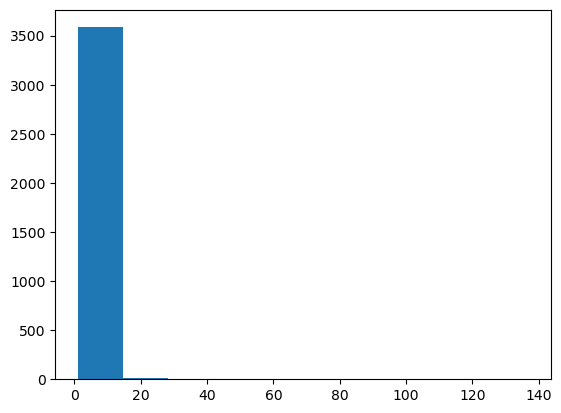

In [49]:
import matplotlib.pyplot as plt

plt.hist([len(c) for c in connected_components])

In [56]:
df = pd.read_csv("/orcd/home/002/jefferyl/Lauffen/data/known_drug_targets.tsv", sep = "\t")
drug = set(df['Unnamed: 0'])
print(len(drug))

233


In [61]:
meta = pd.read_csv("/orcd/home/002/jefferyl/Lauffen/data/metadata_input.csv")

# get drug names in train split
train_drugs = set(meta[meta['split'] == 'train']['drug'])
test_drugs = set(meta[meta['split'] == 'test']['drug'])

print(len(train_drugs), len(test_drugs))

186 47


In [62]:
def numpy_row_to_fp(row):
        """Convert 1D numpy array (0/1) to RDKit ExplicitBitVect"""
        fp = DataStructs.ExplicitBitVect(len(row))
        on_bits = np.flatnonzero(row)
        for i in on_bits:
            fp.SetBit(int(i))
        return fp

In [69]:
with open("/orcd/home/002/jefferyl/Lauffen/ContrastLEMBAS/Contrastive_Learning/data/ecfp4_dict.pkl", "rb") as f:
    ecfp4_dict = pickle.load(f)

with open("/orcd/home/002/jefferyl/Lauffen/ContrastLEMBAS/Contrastive_Learning/data/protein_inter_dict.pkl", "rb") as f:
    protein_inter_dict = pickle.load(f)

In [70]:
print(protein_inter_dict)

{'10-DEBC': ['P11309'], '10-hydroxycamptothecin': ['P11387'], '1,2,3,4,5,6-hexabromocyclohexane': ['O60674'], '12-O-tetradecanoylphorbol-13-acetate': ['P01730', 'Q6UVM3', 'Q9HBA0'], '1400W': ['P29475', 'P35228', 'P60323'], '1,4-butanediol': ['Q9UKM7', 'P14555', 'Q9NZK7'], '16,16-dimethylprostaglandin-e2': ['P15428'], '17,21-dihydroxypregn-4-ene-3,20-dione': ['P04150'], '17-hydroxyprogesterone-caproate': ['P10275', 'P05177', 'P20813', 'P20815', 'P03372', 'Q92731', 'Q96RI1', 'O75469', 'P04150', 'P06401'], '1-azakenpaullone': ['P14635', 'P06493', 'Q00535', 'P49841'], '1-deoxymannojirimycin': ['Q16706'], '1-EBIO': ['Q92952', 'Q9H2S1', 'Q9UGI6', 'O15554'], '1-hexadecanal': ['P07108', 'P08100'], '1-naphthyl-PP1': ['P12931', 'P54760', 'P12931'], '1-octanol': ['P17302', 'P57773', 'Q9Y6H8', 'P35212', 'P36382', 'P48165', 'Q9UKL4', 'P08034', 'P29033', 'O75712', 'Q9NTQ9', 'O95377', 'O95452', 'Q6PEY0', 'P36383', 'Q5T442', 'Q8NFK1', 'Q9UKL4', 'Q8N144', 'Q96KN9', 'Q8NFK1'], '1-phenylbiguanide': ['P46

In [68]:
ecfp4_dict['CCCCCS(=O)(=O)CCCCCCCCCCn1c(c(C)c2cc(O)ccc12)-c1ccc(O)cc1']

KeyError: 'CCCCCS(=O)(=O)CCCCCCCCCCn1c(c(C)c2cc(O)ccc12)-c1ccc(O)cc1'

In [96]:
def get_similar_drugs(all_list_drugs, ecfp4_dict, filter_list_drugs, threshold = 0.4):
    """ Finds similar drugs in all_list_drugs that are similar to any drug in filter_list_drugs based on Tanimoto similarity of ECFP4 fingerprints. 

    Args:
        all_list_drugs (list): A list of all drug SMILES strings.
        ecfp4_dict (dict): A dictionary mapping drug SMILES strings to their ECFP4 fingerprints (for all_list_drugs).
        filter_list_drugs (list): A list of drug SMILES strings to filter by.
        threshold (float): The similarity threshold above which drugs are considered similar.

    Returns:
        set: A set of drug SMILES from all_list_drugs that are considered similar to any drug in filter_list_drugs.
    """
    ecfp4_fingerprint = [ecfp4_dict[smi] for smi in all_list_drugs]
    fps = [numpy_row_to_fp(ecfp4) for ecfp4 in ecfp4_fingerprint]

    similar_drugs = set()
    for drug in filter_list_drugs:
        mol = Chem.MolFromSmiles(drug)
        target_fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
        sims = DataStructs.BulkTanimotoSimilarity(target_fp, fps)
        arr = np.array(sims)
        indices = np.where(arr > threshold)[0]
        similar_drugs.update(all_list_drugs[idx] for idx in indices)

    return similar_drugs

In [94]:
print(len(test_drugs))

47


In [97]:
similar_drugs = get_similar_drugs([drug for drug in ecfp4_dict], ecfp4_dict, test_drugs)
print(len(similar_drugs))

138


In [83]:
count = 0
for drug in train_drugs:
    if drug not in ecfp4_dict:
        count += 1
    print(drug)
for drug in test_drugs:
    if drug not in ecfp4_dict:
        count += 1


CCCCCS(=O)(=O)CCCCCCCCCCn1c(c(C)c2cc(O)ccc12)-c1ccc(O)cc1
CN(C1CCCCC1)C(=O)c1sc2nc3ccc(N)cc3n2c1C
Cc1ncc(CN2CCC(=CC2)c2ccccc2)c(N)n1
C(C1=NCCN1)c1cccc2ccccc12
Ic1ccc(CCNC(=N)SCCCc2c[nH]cn2)cc1
C1CCC(CC1)n1cnc2c(Nc3ccc(cc3)N3CCOCC3)nc(Oc3cccc4ccccc34)nc12
CC(C)(Cc1c[nH]c2ccc(Cl)cc12)NCCOc1ccccc1OCC1CC1
Nc1nc(NCCc2ccc(O)cc2)nc2nc(nn12)-c1ccco1
C[C@H](CCC(O)=O)[C@H]1CC[C@H]2[C@@H]3[C@H](O)C[C@@H]4C[C@H](O)CC[C@]4(C)[C@H]3C[C@H](O)[C@]12C
C\C1=C/CC[C@@]2(C)O[C@@H]2[C@H]2OC(=O)C(=C)[C@@H]2CC1
O=c1cc(oc2c(cccc12)-c1ccccc1)N1CCNCC1
COc1cc(ccc1Nc1ncc2N(C)C(=O)c3ccccc3N(C)c2n1)C(=O)N1CCC(CC1)N1CCN(C)CC1
CC(C)CC(NC(=O)N1CCCCCC1)C(=O)NC(Cc2cn(C)c3ccccc23)C(=O)NC(Cc4ccccn4)C(=O)O
CN(C)c1ccc(cc1)\C=C1/C(=O)Nc2ccccc12
CC(=O)NCCc1c(Cc2ccccc2)[nH]c2ccccc12
CNC(=O)c1ccccc1Sc1ccc2c(\C=C\c3ccccn3)n[nH]c2c1
Cc1ccc(cc1)S(=O)(=O)Nc1nc2ccccc2nc1Nc1ccc2nsnc2c1
CCc1cc2N(Cc3ccc(cc3)-c3ccccc3-c3nnn[nH]3)C(=O)CCc2c(CC)n1
CCCCCCCCCCCC1C(=O)C(=O)CC(=O)C1=O
OC(c1ccc(cc1)N(CC(F)(F)F)S(=O)(=O)c1ccccc1)(C(F)(F)F)C(F)(F

In [89]:
mol1 = Chem.MolFromSmiles('CCCCCS(=O)(=O)CCCCCCCCCCN1C2=C(C=C(C=C2)O)C(=C1C3=CC=C(C=C3)O)C')
mol2 = Chem.MolFromSmiles('CCCCCS(=O)(=O)CCCCCCCCCCn1c(c(C)c2cc(O)ccc12)-c1ccc(O)cc1')
fp1 = AllChem.GetMorganFingerprintAsBitVect(mol1, radius=2, nBits=2048)
fp2 = AllChem.GetMorganFingerprintAsBitVect(mol2, radius=2, nBits=2048)
similarity = DataStructs.TanimotoSimilarity(fp1, fp2)
print(similarity)

1.0


In [87]:
for drug in test_drugs:
    for drug in test_drugs:
        if drug and drug2:
            mol1 = Chem.MolFromSmiles(drug)
            mol2 = Chem.MolFromSmiles(drug2)
            fp1 = AllChem.GetMorganFingerprintAsBitVect(mol1, radius=2, nBits=2048)
            fp2 = AllChem.GetMorganFingerprintAsBitVect(mol2, radius=2, nBits=2048)
            similarity = DataStructs.TanimotoSimilarity(fp1, fp2)
            print(f"Similarity between {drug} and {drug2}: {similarity}")

Similarity between CN(C)CCC(c1ccccc1)c1ccccn1 and Oc1ccc(cc1)-c1nc(c([nH]1)-c1ccncc1)-c1ccc(F)cc1: 0.1016949152542373
Similarity between C1CCC(CC1)Nc2nc(Nc3ccc(cc3)N4CCOCC4)nc5[nH]cnc25 and Oc1ccc(cc1)-c1nc(c([nH]1)-c1ccncc1)-c1ccc(F)cc1: 0.0759493670886076
Similarity between C[C@@H](CN1CC(=O)NC(=O)C1)N1CC(=O)NC(=O)C1 and Oc1ccc(cc1)-c1nc(c([nH]1)-c1ccncc1)-c1ccc(F)cc1: 0.034482758620689655
Similarity between CCN(CC)CC(=O)Nc1c(C)cccc1C and Oc1ccc(cc1)-c1nc(c([nH]1)-c1ccncc1)-c1ccc(F)cc1: 0.06666666666666667
Similarity between CN1CCN(Cc2ccc(cc2)C(=O)Nc2ccc(C)c(Nc3nc(cs3)-c3cccnc3)c2)CC1 and Oc1ccc(cc1)-c1nc(c([nH]1)-c1ccncc1)-c1ccc(F)cc1: 0.10989010989010989
Similarity between O\N=C1/C(Nc2ccccc12)=C1/C(=O)Nc2cc(Br)ccc12 and Oc1ccc(cc1)-c1nc(c([nH]1)-c1ccncc1)-c1ccc(F)cc1: 0.07142857142857142
Similarity between CCCCC1C(=O)N(N(C1=O)c1ccccc1)c1ccccc1 and Oc1ccc(cc1)-c1nc(c([nH]1)-c1ccncc1)-c1ccc(F)cc1: 0.05
Similarity between O=C1NC(=O)c2cc(Nc3ccccc3)c(Nc3ccccc3)cc12 and Oc1ccc(cc1)-c1nc(c

In [72]:
import pubchempy as pcp
compounds = pcp.get_compounds("ZK-164015", namespace='name')

In [76]:
print(protein_inter_dict["ZK-164015"])

['P03372', 'Q92731']


In [80]:
# find non-zero columns
new = df[df['Unnamed: 0'] == "CCCCCS(=O)(=O)CCCCCCCCCCn1c(c(C)c2cc(O)ccc12)-c1ccc(O)cc1"]
non_zero_columns = new.loc[:, (new != 0).any(axis=0)]

In [81]:
non_zero_columns

,Unnamed: 0,P03372,Q92731
19,CCCCCS(=O)(=O)CCCCCCCCCCn1c(c(C)c2cc(O)ccc12)-...,1,1


In [100]:
with open("/orcd/home/002/jefferyl/Lauffen/ContrastLEMBAS/Contrastive_Learning/data/protein_inter_dict.pkl", "rb") as f:
    protein_inter_dict_dict = pickle.load(f)

with open("/orcd/home/002/jefferyl/Lauffen/ContrastLEMBAS/Contrastive_Learning/data/smiles_dict.pkl", "rb") as f:
    smiles_dict = pickle.load(f)

new_dict = {}
for drug, proteins in protein_inter_dict_dict.items():
    if drug in smiles_dict:
        new_dict[smiles_dict[drug]] = proteins

with open("/orcd/home/002/jefferyl/Lauffen/ContrastLEMBAS/Contrastive_Learning/data/protein_inter_dict.pkl", "wb") as f:
    pickle.dump(new_dict, f)

In [101]:
with open("/orcd/home/002/jefferyl/Lauffen/ContrastLEMBAS/Contrastive_Learning/data/protein_inter_dict.pkl", "rb") as f:
    protein_inter_dict_dict = pickle.load(f)

print(protein_inter_dict_dict)

{'CCN(CC)CCCCN1C2=CC=CC=C2OC3=C1C=C(C=C3)Cl': ['P11309'], 'CCC1(C2=C(COC1=O)C(=O)N3CC4=C(C3=C2)N=C5C=CC(=CC5=C4)O)O': ['P11387'], 'C1(C(C(C(C(C1Br)Br)Br)Br)Br)Br': ['O60674'], 'CCCCCCCCCCCCCC(=O)OC1C(C2(C(C=C(CC3(C2C=C(C3=O)C)O)CO)C4C1(C4(C)C)OC(=O)C)O)C': ['P01730', 'Q6UVM3', 'Q9HBA0'], 'CC(=NCC1=CC=CC(=C1)CN)N': ['P29475', 'P35228', 'P60323'], 'C(CCO)CO': ['Q9UKM7', 'P14555', 'Q9NZK7'], 'CCCCC(C)(C)C(C=CC1C(CC(=O)C1CC=CCCCC(=O)O)O)O': ['P15428'], 'CC12CCC(=O)C=C1CCC3C2CCC4(C3CCC4(C(=O)CO)O)C': ['P10275'], 'CCCCCC(=O)OC1(CCC2C1(CCC3C2CCC4=CC(=O)CCC34C)C)C(=O)C': ['P10275', 'P05177', 'P20813', 'P20815', 'P03372', 'Q92731', 'Q96RI1', 'O75469', 'P04150', 'P06401'], 'C1C2=C(C3=C(C=CC=N3)NC1=O)NC4=C2C=C(C=C4)Br': ['P14635', 'P06493', 'Q00535', 'P49841'], 'C1C(C(C(C(N1)CO)O)O)O': ['Q9UHE5'], 'CCN1C2=CC=CC=C2NC1=O': ['Q92952', 'Q9H2S1', 'Q9UGI6', 'O15554'], 'CCCCCCCCCCCCCCCC=O': ['P07108', 'P08100'], 'CC(C)(C)N1C2=NC=NC(=C2C(=N1)C3=CC=CC4=CC=CC=C43)N': ['P12931', 'P54760', 'P12931'], 'CCCCCC

In [103]:
similar_drugs = get_similar_drugs([drug for drug in ecfp4_dict], ecfp4_dict, test_drugs, threshold = 0.4)

with open("/orcd/home/002/jefferyl/Lauffen/ContrastLEMBAS/Contrastive_Learning/data/protein_inter_dict.pkl", "rb") as f:
    protein_inter_dict_dict = pickle.load(f)

inter_dict_train = {drug: protein_inter_dict_dict[drug] for drug in protein_inter_dict_dict if drug not in similar_drugs}
inter_dict_test = {drug: protein_inter_dict_dict[drug] for drug in protein_inter_dict_dict if drug in similar_drugs}

In [105]:
with open("/orcd/home/002/jefferyl/Lauffen/ContrastLEMBAS/Contrastive_Learning/data/protein_inter_dict_train.pkl", "wb") as f:
    pickle.dump(inter_dict_train, f)

with open("/orcd/home/002/jefferyl/Lauffen/ContrastLEMBAS/Contrastive_Learning/data/protein_inter_dict_test.pkl", "wb") as f:
    pickle.dump(inter_dict_test, f)

In [104]:
print(len(similar_drugs))
print(len(inter_dict_train))
print(len(inter_dict_test))

print(inter_dict_train)

138
5420
138
{'CCN(CC)CCCCN1C2=CC=CC=C2OC3=C1C=C(C=C3)Cl': ['P11309'], 'CCC1(C2=C(COC1=O)C(=O)N3CC4=C(C3=C2)N=C5C=CC(=CC5=C4)O)O': ['P11387'], 'C1(C(C(C(C(C1Br)Br)Br)Br)Br)Br': ['O60674'], 'CCCCCCCCCCCCCC(=O)OC1C(C2(C(C=C(CC3(C2C=C(C3=O)C)O)CO)C4C1(C4(C)C)OC(=O)C)O)C': ['P01730', 'Q6UVM3', 'Q9HBA0'], 'CC(=NCC1=CC=CC(=C1)CN)N': ['P29475', 'P35228', 'P60323'], 'C(CCO)CO': ['Q9UKM7', 'P14555', 'Q9NZK7'], 'CCCCC(C)(C)C(C=CC1C(CC(=O)C1CC=CCCCC(=O)O)O)O': ['P15428'], 'CC12CCC(=O)C=C1CCC3C2CCC4(C3CCC4(C(=O)CO)O)C': ['P10275'], 'CCCCCC(=O)OC1(CCC2C1(CCC3C2CCC4=CC(=O)CCC34C)C)C(=O)C': ['P10275', 'P05177', 'P20813', 'P20815', 'P03372', 'Q92731', 'Q96RI1', 'O75469', 'P04150', 'P06401'], 'C1C2=C(C3=C(C=CC=N3)NC1=O)NC4=C2C=C(C=C4)Br': ['P14635', 'P06493', 'Q00535', 'P49841'], 'C1C(C(C(C(N1)CO)O)O)O': ['Q9UHE5'], 'CCN1C2=CC=CC=C2NC1=O': ['Q92952', 'Q9H2S1', 'Q9UGI6', 'O15554'], 'CCCCCCCCCCCCCCCC=O': ['P07108', 'P08100'], 'CC(C)(C)N1C2=NC=NC(=C2C(=N1)C3=CC=CC4=CC=CC=C43)N': ['P12931', 'P54760', 'P129

In [1]:
import sys
import os

sys.path.append('/home/jefferyl/ContrastLEMBAS/Contrastive_Learning/code/data_processing')

In [7]:
import data_drug_similarity, data_utils

In [ ]:
data_utils.process_broad_repurposing_data("/orcd/home/002/jefferyl/ContrastLEMBAS/Contrastive_Learning/data/broad_repurposing_data/raw_drug_repurposing_data.txt", )

In [ ]:
import pickle

with open("/orcd/home/002/jefferyl/ContrastLEMBAS/Contrastive_Learning/data/drug_data/smiles_to_ecfp4.pkl", "rb") as f:
    ecfp4_dict = pickle.load(f)

with open("/orcd/home/002/jefferyl/ContrastLEMBAS/Contrastive_Learning/data/drug_data/smiles_to_ecfp4.pkl", "rb") as f:
    ecfp4_dict = pickle.load(f)
    
print(len(list(ecfp4_dict.keys())))
data_drug_similarity.generate_similarity_mat(list(ecfp4_dict.keys()), ecfp4_dict, save = True, save_path = "/orcd/home/002/jefferyl/Lauffen/ContrastLEMBAS/Contrastive_Learning/data/drug_data")

0


0it [00:00, ?it/s]


(array([], shape=(0, 0), dtype=float32), {})

In [1]:
import torch
loaded_data = torch.load("/orcd/home/002/jefferyl/Lauffen/ContrastLEMBAS/Contrastive_Learning/data/drug_data/")

FileNotFoundError: [Errno 2] No such file or directory: '/orcd/home/002/jefferyl/Lauffen/ContrastLEMBAS/Contrastive_Learning/data/drug_data/'

In [5]:
import pickle
with open("/home/jefferyl/ContrastLEMBAS/contrastive_model/data/protein_data/uniprot_to_fasta.pkl", "rb") as f:
    uniprot_to_fasta = pickle.load(f)

print(uniprot_to_fasta.keys())
print(uniprot_to_fasta['Q96KB5'])

dict_keys(['Q13627', 'Q96KB5', 'Q9NYX4', 'O95139', 'P05981', 'Q9Y5R2', 'Q9H9B1', 'O15399', 'Q02153', 'P51511', 'Q08828', 'Q9BY49', 'P10826', 'P00439', 'Q15738', 'P18031', 'Q14571', 'Q96A54', 'Q9NYK1', 'P41594', 'P41439', 'P35408', 'P09238', 'Q99466', 'O60939', 'P18545', 'Q9HBW0', 'P43681', 'Q9Y6D6', 'Q0ZFF5', 'P49674', 'P35610', 'Q92506', 'P35626', 'Q92538', 'P51449', 'P18089', 'P0DMS8', 'P10415', 'P25105', 'P18505', 'P25116', 'Q9H1R3', 'Q99259', 'Q16706', 'Q09428', 'Q05469', 'P34949', 'Q4KMG0', 'P42701', 'Q16718', 'P27448', 'Q9Y243', 'P25024', 'Q9NY91', 'A0A223PYC5', 'P30519', 'Q9UHD2', 'Q8WUX1', 'P51810', 'Q96GD0', 'P53582', 'Q9Y468', 'P15538', 'Q9H2M3', 'P17931', 'Q96KS0', 'Q15596', 'P20292', 'Q02156', 'P27707', 'P51512', 'P30542', 'O75973', 'Q9BV23', 'Q16602', 'P48664', 'P03923', 'Q13131', 'Q9P286', 'O94759', 'Q15077', 'Q0EFA5', 'Q96PR1', 'P17540', 'Q5VTY9', 'Q8NCM2', 'P01189', 'O00141', 'Q9Y6Y9', 'Q15842', 'P23434', 'O94788', 'P31645', 'P13631', 'O95069', 'P50416', 'Q9Y646', 'P427

In [10]:
def process_uniprot_to_fasta(uniprot_to_fasta_dict, output_path):
    """ Processes a dictionary mapping UniProt accession numbers to FASTA sequences by removing the > ---- line and only getting string of FASTA.
    
    Args:
        uniprot_to_fasta_dict (dict): A dictionary mapping UniProt accession numbers to their corresponding FASTA sequences.
    """
    for accession in uniprot_to_fasta_dict:
        uniprot_to_fasta_dict[accession] = uniprot_to_fasta_dict[accession].split("\n", 1)[1].replace(" ", "").replace("\n", "")

    with open(f"{output_path}/processed_uniprot_to_fasta.pkl", "wb") as f:
        pickle.dump(uniprot_to_fasta_dict, f)
    return uniprot_to_fasta_dict

In [11]:
uniprot_to_fasta_dict = process_uniprot_to_fasta(uniprot_to_fasta, "/home/jefferyl/ContrastLEMBAS/contrastive_model/data/protein_data")

In [13]:
def write_mmseqs_fasta(uniprot_to_fasta_dict, output_path):
    """ Writes a FASTA file in the format required for MMseqs2 from a dictionary mapping UniProt accession numbers to FASTA sequences.
    
    Args:
        uniprot_to_fasta_dict (dict): A dictionary mapping UniProt accession numbers to their corresponding FASTA sequences.
        output_path (str): The path where the output FASTA file should be saved.
    """

    with open(output_path, "w") as f:
        for accession, fasta in uniprot_to_fasta_dict.items():
            f.write(f">{accession}\n")
            f.write(f"{fasta}\n")

In [14]:
write_mmseqs_fasta(uniprot_to_fasta_dict, "/home/jefferyl/ContrastLEMBAS/contrastive_model/data/protein_data/uniprot_sequences.fasta")

In [1]:
import pickle
import pandas as pd
import torch
import numpy as np
import os

In [14]:
def mmseqs_results_to_adj(mmseqs_results, uniprot_ids, type = "torch", save = False, save_path = None):
    """ Converts MMseqs2 results to an adjacency matrix of similarity. MMseqs2 calculated similarity are stored in adjacency matrix and uncalculated pairs
    are assumed to have similarity of 0. The resulting adjacency matrix can be saved to disk as a PyTorch tensor or a NumPy array.

    Args:
        mmseqs_results (df): A dataframe containing the results of MMSeqs2 alignment.
        uniprot_ids (list): A list of UniProt IDs to include in the adjacency matrix.
        output_path (str): The path where the output adjacency matrix file should be saved.
        type (str): The type of adjacency matrix to create - "torch" or "numpy".
        save (bool): Whether to save the resulting adjacency matrix to disk.
        save_path (str): The path where the adjacency matrix should be saved if save is True.
    """
    if type == "torch":
        adj = torch.zeros((len(uniprot_ids), len(uniprot_ids)))
    else:
        adj = np.zeros((len(uniprot_ids), len(uniprot_ids)))

    uniprot_to_index = {uniprot_id: i for i, uniprot_id in enumerate(uniprot_ids)}

    for index, row in mmseqs_results.iterrows():
        accession1, accession2 = row["query_id"], row["target_id"]
        similarity = row["seq_identity"]

        # set similarity in adjacency matrix (undirected)
        adj[uniprot_to_index[accession1], uniprot_to_index[accession2]] = similarity
        adj[uniprot_to_index[accession2], uniprot_to_index[accession1]] = similarity

    # make diagonals 1 (protein similarity with itself is 1) - sometimes mmseqs does local alignment so < 1
    for i in range(len(uniprot_ids)):
        adj[i, i] = 1.0
        
    if save and save_path:

        if type == "torch":
            save_data = {"similarity" : adj,
                         "uniprot_to_index": uniprot_to_index}
            torch.save(save_data, f"{save_path}/protein_similarity.pt")
        
        else:
            np.savez(f"{save_path}/protein_similarity.npz", similarity=adj, uniprot_to_index=uniprot_to_index)
    return adj

In [3]:
def load_mmseqs_results(mmseqs_results_path):
    """ Loads MMseqs2 results from a file and returns them as a dataframe.
    
    Args:
        mmseqs_results_path (str): The path to the MMseqs2 results file.
    """
    mmseqs_results = pd.read_csv(mmseqs_results_path, sep="\t", header=None, names=["query_id", "target_id", "seq_identity", "alignment_length", "mismatches", "gap_opens", "q.start", "q.end", "t.start", "t.end", "e_value", "bit_score"])
    return mmseqs_results

In [10]:
mmseqs_results = load_mmseqs_results('/orcd/home/002/jefferyl/ContrastLEMBAS/contrastive_model/data/mmseqs_results/results.tsv')
with open("/orcd/home/002/jefferyl/ContrastLEMBAS/contrastive_model/data/protein_data/processed_uniprot_to_fasta.pkl", "rb") as f:
    uniprot_to_fasta_dict = pickle.load(f)
uniprot_ids = list(uniprot_to_fasta_dict.keys())

In [6]:
with open("/orcd/home/002/jefferyl/ContrastLEMBAS/contrastive_model/data/protein_data/uniprot_to_fasta.pkl", "rb") as f:
    uniprot_to_fasta_dict = pickle.load(f)

print(uniprot_to_fasta_dict.keys())

dict_keys(['Q13627', 'Q96KB5', 'Q9NYX4', 'O95139', 'P05981', 'Q9Y5R2', 'Q9H9B1', 'O15399', 'Q02153', 'P51511', 'Q08828', 'Q9BY49', 'P10826', 'P00439', 'Q15738', 'P18031', 'Q14571', 'Q96A54', 'Q9NYK1', 'P41594', 'P41439', 'P35408', 'P09238', 'Q99466', 'O60939', 'P18545', 'Q9HBW0', 'P43681', 'Q9Y6D6', 'Q0ZFF5', 'P49674', 'P35610', 'Q92506', 'P35626', 'Q92538', 'P51449', 'P18089', 'P0DMS8', 'P10415', 'P25105', 'P18505', 'P25116', 'Q9H1R3', 'Q99259', 'Q16706', 'Q09428', 'Q05469', 'P34949', 'Q4KMG0', 'P42701', 'Q16718', 'P27448', 'Q9Y243', 'P25024', 'Q9NY91', 'A0A223PYC5', 'P30519', 'Q9UHD2', 'Q8WUX1', 'P51810', 'Q96GD0', 'P53582', 'Q9Y468', 'P15538', 'Q9H2M3', 'P17931', 'Q96KS0', 'Q15596', 'P20292', 'Q02156', 'P27707', 'P51512', 'P30542', 'O75973', 'Q9BV23', 'Q16602', 'P48664', 'P03923', 'Q13131', 'Q9P286', 'O94759', 'Q15077', 'Q0EFA5', 'Q96PR1', 'P17540', 'Q5VTY9', 'Q8NCM2', 'P01189', 'O00141', 'Q9Y6Y9', 'Q15842', 'P23434', 'O94788', 'P31645', 'P13631', 'O95069', 'P50416', 'Q9Y646', 'P427

In [ ]:
# see how many uniprot ids are in fasta file

with open("/orcd/home/002/jefferyl/ContrastLEMBAS/contrastive_model/data/protein_data/processed_uniprot_to_fasta.pkl", "rb") as f:
    uniprot_to_fasta_dict = pickle.load(f)
uniprot_ids = list(uniprot_to_fasta_dict.keys())
print(len(set(mmseqs_results["query_id"]).intersection(set(uniprot_ids))))


,query_id,target_id,seq_identity,alignment_length,mismatches,gap_opens,q.start,q.end,t.start,t.end,e_value,bit_score
0,P48544,P48544,1.000,419,0,0,1,419,1,419,1.078000e-284,863
1,P48544,P48051,0.724,421,96,5,1,419,12,414,6.954000e-194,601
2,P48544,P48549,0.666,327,104,3,47,370,40,364,2.079000e-142,452
3,P48544,Q14500,0.555,324,142,2,50,371,43,366,1.811000e-120,388
4,P48544,P48050,0.488,405,170,8,47,419,15,414,1.811000e-120,388
...,...,...,...,...,...,...,...,...,...,...,...,...
91585,Q96LB2,P41231,0.306,124,73,5,36,148,42,163,3.479000e-04,40
91586,Q96LB2,P35372,0.241,269,169,7,36,275,79,341,3.479000e-04,40
91587,Q96LB2,P25106,0.239,296,191,12,8,275,29,318,4.610000e-04,39
91588,Q96LB2,Q15743,0.225,270,179,11,37,281,31,295,4.610000e-04,39


In [11]:
print(len(set(mmseqs_results["query_id"]).intersection(set(uniprot_ids))))

2395


In [12]:
print(len(set(mmseqs_results["target_id"]).intersection(set(uniprot_ids))))

2395


In [15]:
mmseqs_results_to_adj(mmseqs_results, uniprot_ids, type="torch", save=True, save_path="/orcd/home/002/jefferyl/ContrastLEMBAS/contrastive_model/data/protein_data")


tensor([[1.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 1.0000, 0.0000,  ..., 0.0000, 0.2550, 0.0000],
        [0.0000, 0.0000, 1.0000,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 1.0000, 0.0000, 0.0000],
        [0.0000, 0.2550, 0.0000,  ..., 0.0000, 1.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 1.0000]])